In [19]:
import pandas as pd
import re

# 1. Load and clean messy data
df = pd.read_csv('/home/emchatwin/Kelly Lab/ms_qc_processor/input2/bachelorette.csv', skiprows=[1])

elim_cols = [f'ELIM_{i}' for i in range(1, 11)]
date_cols = [f'DATE_{i}' for i in range(1, 11)]
df.columns = ['SHOW', 'SEASON', 'CONTESTANT'] + elim_cols + date_cols
df = df[df['SEASON'] != 'SEASON'].copy()

# Elimination codes
elim_codes = {'E', 'ED', 'EU', 'EQ', 'EF'}

def get_elim_week(row):
    for w in range(1, 11):
        val = row[f'ELIM_{w}']
        if val in elim_codes:
            return w
        if val == 'W':
            return 11
    return 11

df['ELIM_WEEK'] = df.apply(get_elim_week, axis=1)

# First impression rose (week 1 only)
df['FIRST_IMPRESSION_ROSE'] = df['ELIM_1'] == 'R1'

# Helper to parse date code and get group size
def parse_date_code(code):
    if pd.isna(code) or str(code).strip() == '':
        return None, False
    code_str = str(code).strip()
    first_code = code_str.split(',')[0].strip()
    match = re.match(r'D(\d+)', first_code)
    if match:
        size = int(match.group(1))
        return size, (size == 1)
    return 1, True  # fallback

# Build weekly timeline with roses
records = []
for _, row in df.iterrows():
    show = row['SHOW']
    season = row['SEASON']
    contestant = row['CONTESTANT']
    elim_week = row['ELIM_WEEK']
    fir = row['FIRST_IMPRESSION_ROSE']
    for week in range(1, 11):
        alive = week < elim_week
        weekly_rose = elim_week > week
        date_val = row[f'DATE_{week}']
        group_size, is_one_on_one = parse_date_code(date_val)
        has_date = group_size is not None
        date_rose = is_one_on_one
        date_ratio = 1.0 / group_size if has_date else 0.0
        records.append({
            'SHOW': show,
            'SEASON': season,
            'CONTESTANT': contestant,
            'WEEK': week,
            'ALIVE': alive,
            'HAS_DATE': has_date,
            'ONE_ON_ONE': is_one_on_one,
            'DATE_GROUP_SIZE': group_size if has_date else 0,
            'DATE_RATIO': date_ratio,
            'DATE_ROSE': date_rose,
            'WEEKLY_ROSE': weekly_rose,
            'FIRST_IMPRESSION_ROSE': (week == 1 and fir),
            'ELIMINATED_THIS_WEEK': (week == elim_week and elim_week <= 10)
        })

weekly_df = pd.DataFrame(records)
weekly_df.to_csv('contestant_weekly.csv', index=False)
print("Saved contestant_weekly.csv")

Saved contestant_weekly.csv


In [20]:
from sklearn.model_selection import train_test_split

df = pd.read_csv('contestant_weekly.csv')

contestants = df[['SHOW', 'SEASON', 'CONTESTANT']].drop_duplicates()
train_contestants, test_contestants = train_test_split(
    contestants, test_size=0.5, random_state=42, stratify=contestants['SHOW']
)

train_df = df.merge(train_contestants, on=['SHOW', 'SEASON', 'CONTESTANT'], how='inner')
test_df = df.merge(test_contestants, on=['SHOW', 'SEASON', 'CONTESTANT'], how='inner')

train_df.to_csv('train_contestant_weekly.csv', index=False)
test_df.to_csv('test_contestant_weekly.csv', index=False)

print(f"Train size: {len(train_df)} rows, {train_df['CONTESTANT'].nunique()} contestants")
print(f"Test size: {len(test_df)} rows, {test_df['CONTESTANT'].nunique()} contestants")

Train size: 4420 rows, 441 contestants
Test size: 4450 rows, 442 contestants


Train rows: 4420
Week 1: 442 contestants, explained variance PC1: 0.919
Week 2: 442 contestants, explained variance PC1: 0.543
Week 3: 442 contestants, explained variance PC1: 0.542
Week 4: 442 contestants, explained variance PC1: 0.564
Week 5: 442 contestants, explained variance PC1: 0.577
Week 6: 442 contestants, explained variance PC1: 0.632
Week 7: 442 contestants, explained variance PC1: 0.757
Week 8: 442 contestants, explained variance PC1: 1.000
Week 9: 442 contestants, explained variance PC1: 1.000
Week 10: 442 contestants, explained variance PC1: 1.000


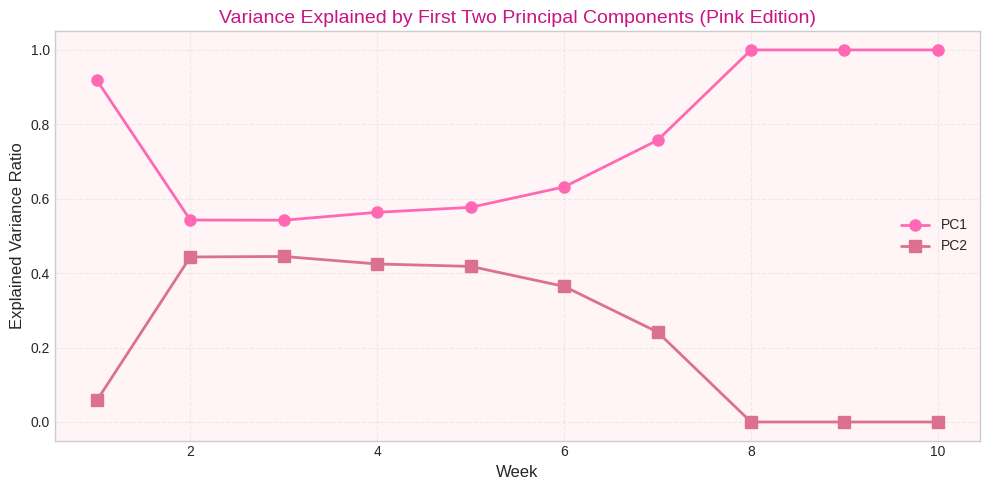

Saved weekly explained variance plot as 'weekly_pca_explained_variance_pink.png'


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Load training data
train = pd.read_csv('train_contestant_weekly.csv')
print(f"Train rows: {len(train)}")

features = ['HAS_DATE', 'ONE_ON_ONE', 'DATE_GROUP_SIZE', 'DATE_RATIO',
            'DATE_ROSE', 'FIRST_IMPRESSION_ROSE']

week_loadings = {}
explained_variances = {}

for week in range(1, 11):
    week_data = train[train['WEEK'] == week].copy()
    if week_data.empty:
        continue
    
    X = week_data[features].copy()
    numeric_cols = ['DATE_GROUP_SIZE', 'DATE_RATIO']
    binary_cols = [c for c in features if c not in numeric_cols]
    scaler = StandardScaler()
    X_numeric = scaler.fit_transform(X[numeric_cols])
    X_scaled = np.hstack([X_numeric, X[binary_cols].values])
    
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    explained_variances[week] = pca.explained_variance_ratio_
    
    loadings = pd.DataFrame(pca.components_[:3].T,
                            columns=['PC1', 'PC2', 'PC3'],
                            index=features)
    week_loadings[week] = loadings
    print(f"Week {week}: {len(X)} contestants, explained variance PC1: {pca.explained_variance_ratio_[0]:.3f}")

# --- Plot explained variance (pink themed) ---
weeks_with_data = list(explained_variances.keys())
explained_pc1 = [explained_variances[w][0] for w in weeks_with_data]
explained_pc2 = [explained_variances[w][1] for w in weeks_with_data]

plt.figure(figsize=(10,5))
plt.plot(weeks_with_data, explained_pc1, 'o-', color='#FF69B4', linewidth=2, markersize=8, label='PC1')
plt.plot(weeks_with_data, explained_pc2, 's-', color='#DB7093', linewidth=2, markersize=8, label='PC2')
plt.xlabel('Week', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.title('Variance Explained by First Two Principal Components (Pink Edition)', fontsize=14, color='#C71585')
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--')
ax = plt.gca()
ax.set_facecolor('#FFF5F7')
plt.tight_layout()
plt.savefig('weekly_pca_explained_variance_pink.png', dpi=150)
plt.show()
print("Saved weekly explained variance plot as 'weekly_pca_explained_variance_pink.png'")

# --- Heatmap of PC1 loadings (pink colormap) ---
pc1_loadings_df = pd.DataFrame({
    week: week_loadings[week]['PC1'] for week in weeks_with_data
}).T

# Custom pink colormap
pink_cmap = LinearSegmentedColormap.from_list('Pinks', ['#FFF0F5', '#FFB6C1', '#FF69B4', '#C71585'], N=256)

plt.figure(figsize=(12,6))
im = plt.imshow(pc1_loadings_df.values, cmap=pink_cmap, aspect='auto', vmin=-1, vmax=1)
plt.colorbar(im, label='PC1 Loading')
plt.xticks(range(len(features)), features, rotation=45, ha='right')
plt.yticks(range(len(weeks_with_data)), weeks_with_data)
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Week', fontsize=12)
plt.title('PC1 Loadings per Week (Pink Heatmap)', fontsize=14, color='#C71585')
plt.tight_layout()
plt.savefig('weekly_pc1_loadings_heatmap_pink.png', dpi=150)
plt.show()
print("Saved PC1 loadings heatmap as 'weekly_pc1_loadings_heatmap_pink.png'")

# Save loadings
for week, loadings_df in week_loadings.items():
    loadings_df.to_csv(f'week_{week}_pca_loadings.csv')
print("Saved weekly loadings to 'week_*_pca_loadings.csv' files")

Bachelor Season 13: 250 rows, 25 contestants
Saved all data to 'bachelor_s13_all_data.csv'
Winner: 13_MELISSA_R

WEEKLY DETAILS FOR Bachelor SEASON 13

--- Week 1 ---
  On a date:           None
  One-on-one dates:    None
  Received a rose:     ['13_MELISSA_R', '13_MOLLY_M', '13_JILLIAN_H', '13_NAOMI_C', '13_STEPHANIE_H', '13_LAUREN_W', '13_MEGAN_P', '13_SHANNON_B', '13_NIKKI_K', '13_ERICA_D', '13_KARI_F', '13_NATALIE_G', '13_RAQUEL_M', '13_SHARON_S', '13_LISA_G']
  Eliminated:          ['13_ANN_L', '13_DOMINIQUE_C', '13_EMILY_H', '13_JACKIE_H', '13_JULIE_D', '13_NICOLE_M', '13_RENEE_S', '13_SHELBY_G', '13_STACIA_M', '13_TREASURE_M']

--- Week 2 ---
  On a date:           ['13_MELISSA_R', '13_MOLLY_M', '13_JILLIAN_H', '13_NAOMI_C', '13_LAUREN_W', '13_NIKKI_K', '13_ERICA_D', '13_KARI_F', '13_NATALIE_G', '13_SHARON_S']
  One-on-one dates:    ['13_MELISSA_R', '13_JILLIAN_H']
  Received a rose:     ['13_MELISSA_R', '13_MOLLY_M', '13_JILLIAN_H', '13_NAOMI_C', '13_STEPHANIE_H', '13_LAUREN_W

/home/emchatwin/Kelly Lab/.lab/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:545: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var
/home/emchatwin/Kelly Lab/.lab/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:545: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var


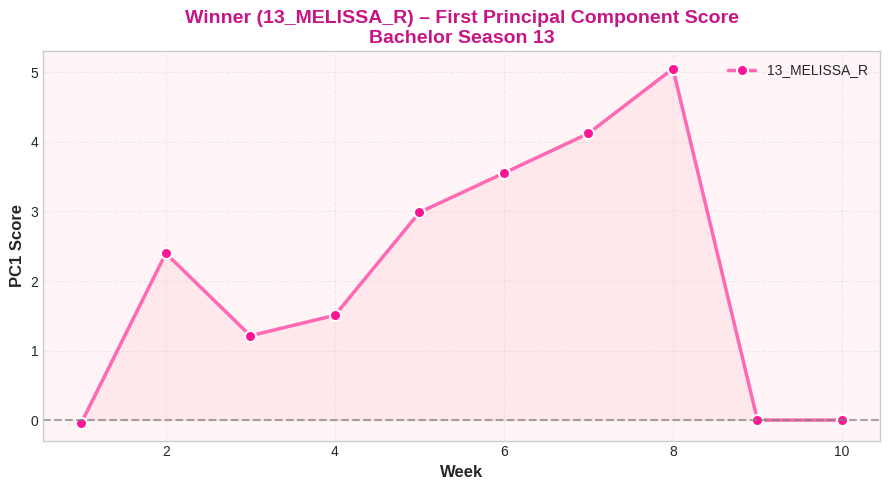


Saved pretty pink plot as 'bachelor_s13_winner_pc1_trajectory_pink.png'


Bachelor Season 13: 250 rows, 25 contestants
Saved all raw data to 'bachelor_s13_all_data.csv'
Winner: 13_MELISSA_R

WEEKLY DETAILS FOR Bachelor SEASON 13

--- Week 1 ---
  On a date:           None
  One-on-one dates:    None
  Received a rose:     ['13_MELISSA_R', '13_MOLLY_M', '13_JILLIAN_H', '13_NAOMI_C', '13_STEPHANIE_H', '13_LAUREN_W', '13_MEGAN_P', '13_SHANNON_B', '13_NIKKI_K', '13_ERICA_D', '13_KARI_F', '13_NATALIE_G', '13_RAQUEL_M', '13_SHARON_S', '13_LISA_G']
  Eliminated:          ['13_ANN_L', '13_DOMINIQUE_C', '13_EMILY_H', '13_JACKIE_H', '13_JULIE_D', '13_NICOLE_M', '13_RENEE_S', '13_SHELBY_G', '13_STACIA_M', '13_TREASURE_M']

--- Week 2 ---
  On a date:           ['13_MELISSA_R', '13_MOLLY_M', '13_JILLIAN_H', '13_NAOMI_C', '13_LAUREN_W', '13_NIKKI_K', '13_ERICA_D', '13_KARI_F', '13_NATALIE_G', '13_SHARON_S']
  One-on-one dates:    ['13_MELISSA_R', '13_JILLIAN_H']
  Received a rose:     ['13_MELISSA_R', '13_MOLLY_M', '13_JILLIAN_H', '13_NAOMI_C', '13_STEPHANIE_H', '13_LAUR

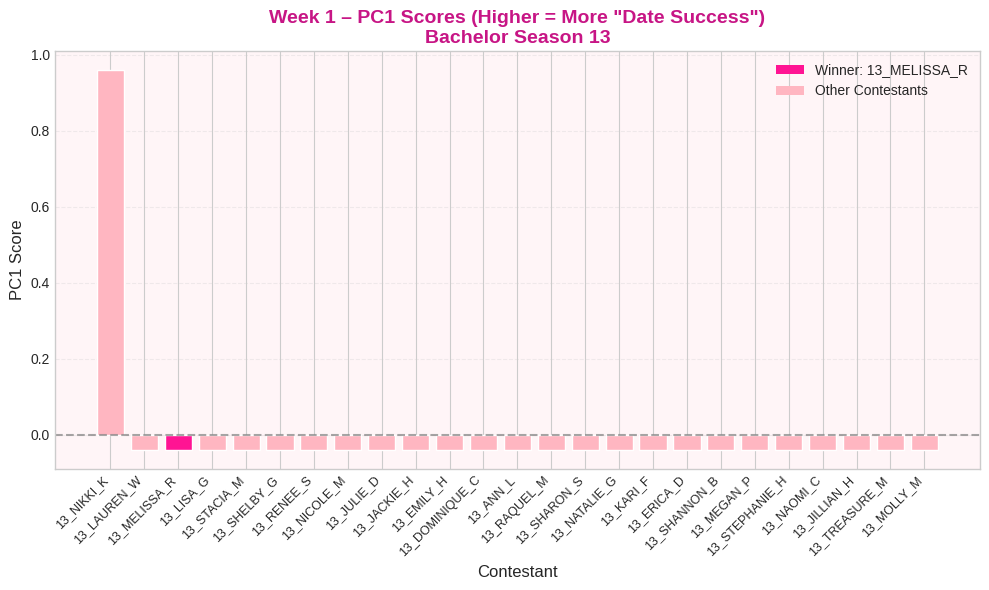

  Saved plot: bachelor_s13_week1_pc1_scores.png

Week 2: 25 contestants, PC1 explains 0.570 of variance
  13_MELISSA_R's PC1 score: 2.398
  Top PC1 loadings:
    Positive: {'ONE_ON_ONE': 0.654325427593717, 'HAS_DATE': 0.607688143675382}
    Negative: {'FIRST_IMPRESSION_ROSE': 0.0, 'DATE_RATIO': 0.14105869183473618}


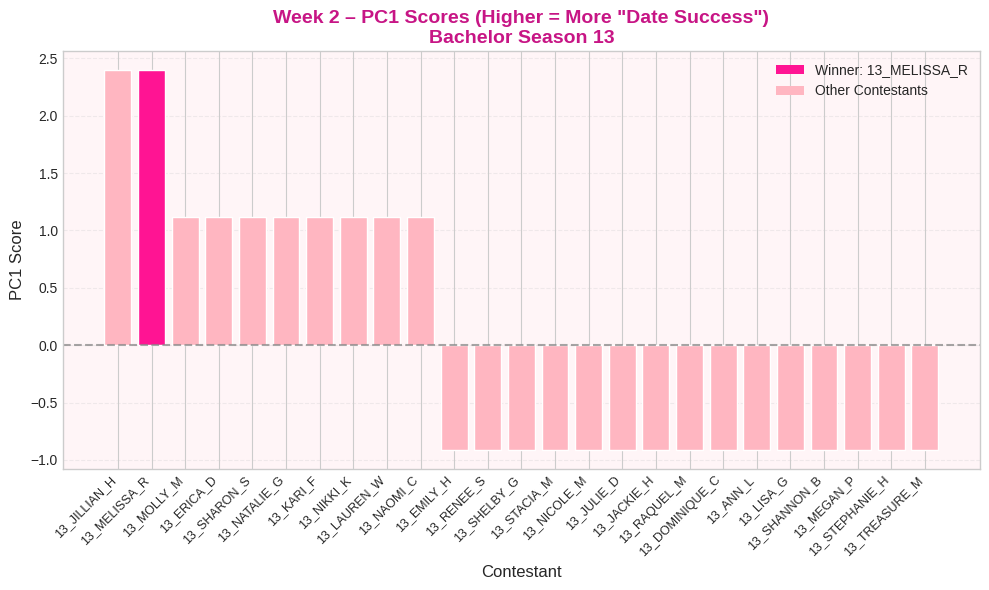

  Saved plot: bachelor_s13_week2_pc1_scores.png

Week 3: 25 contestants, PC1 explains 0.576 of variance
  13_MELISSA_R's PC1 score: 1.213
  Top PC1 loadings:
    Positive: {'ONE_ON_ONE': 0.6647156220320789, 'HAS_DATE': 0.5998573296113799}
    Negative: {'FIRST_IMPRESSION_ROSE': 0.0, 'DATE_RATIO': 0.14629861334094452}


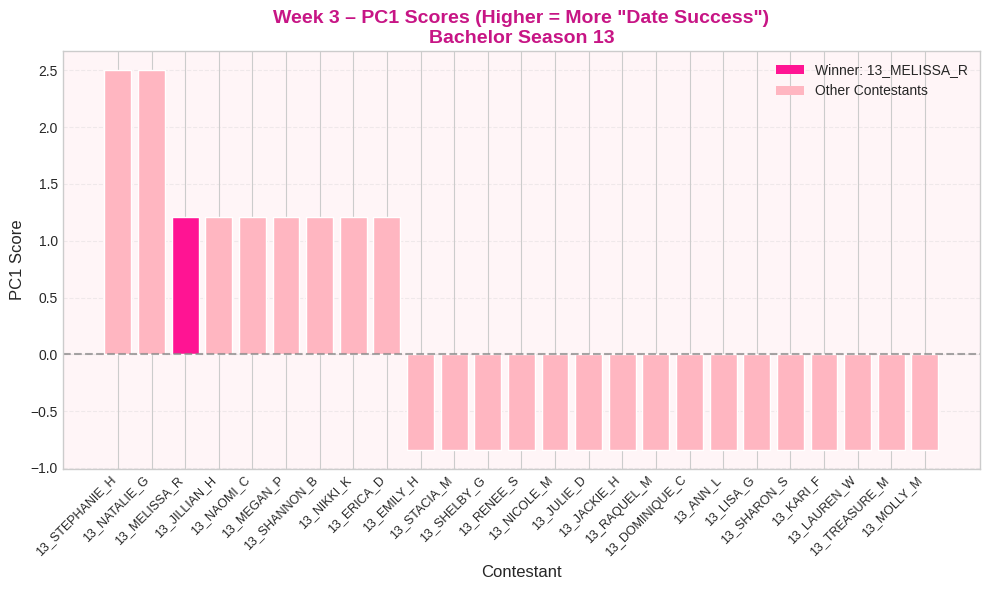

  Saved plot: bachelor_s13_week3_pc1_scores.png

Week 4: 25 contestants, PC1 explains 0.660 of variance
  13_MELISSA_R's PC1 score: 1.507
  Top PC1 loadings:
    Positive: {'HAS_DATE': 0.6545234431266892, 'ONE_ON_ONE': 0.6445348935757912}
    Negative: {'FIRST_IMPRESSION_ROSE': 0.0, 'DATE_RATIO': 0.07083988525405391}


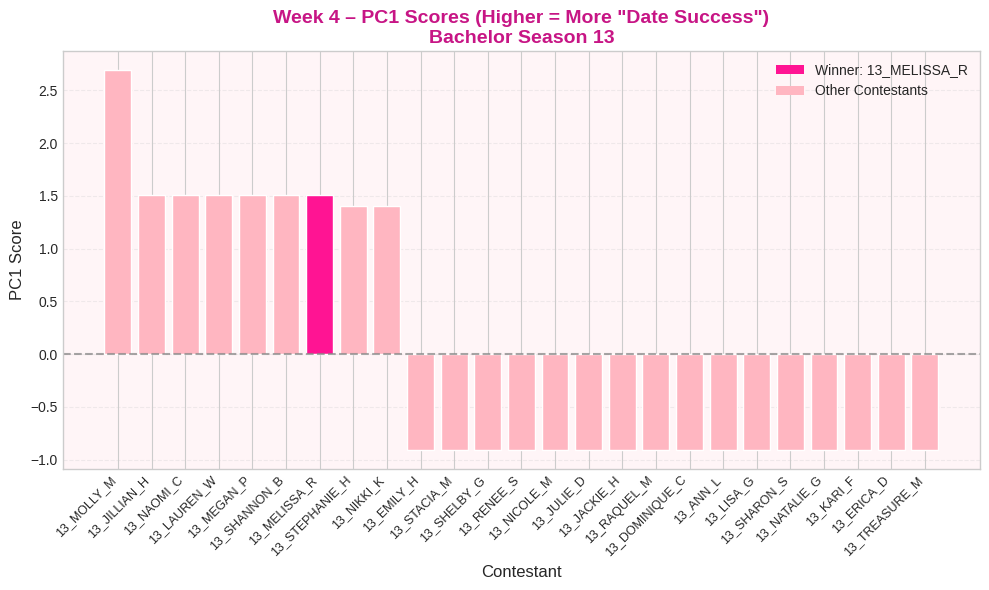

  Saved plot: bachelor_s13_week4_pc1_scores.png

Week 5: 25 contestants, PC1 explains 0.760 of variance
  13_MELISSA_R's PC1 score: 2.986
  Top PC1 loadings:
    Positive: {'ONE_ON_ONE': 0.6799859258388287, 'HAS_DATE': 0.6403913147988072}
    Negative: {'FIRST_IMPRESSION_ROSE': 0.0, 'DATE_RATIO': 0.13623028592036268}


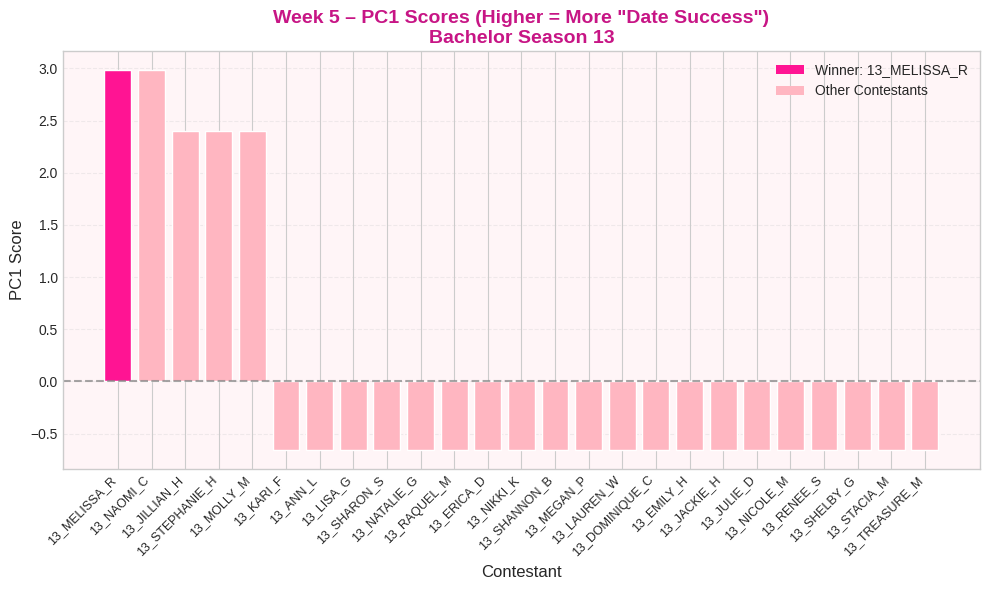

  Saved plot: bachelor_s13_week5_pc1_scores.png

Week 6: 25 contestants, PC1 explains 1.000 of variance
  13_MELISSA_R's PC1 score: 3.552
  Top PC1 loadings:
    Positive: {'ONE_ON_ONE': 0.6450673227388852, 'HAS_DATE': 0.6450673227388848}
    Negative: {'FIRST_IMPRESSION_ROSE': -0.0, 'DATE_GROUP_SIZE': 0.23648558678347587}


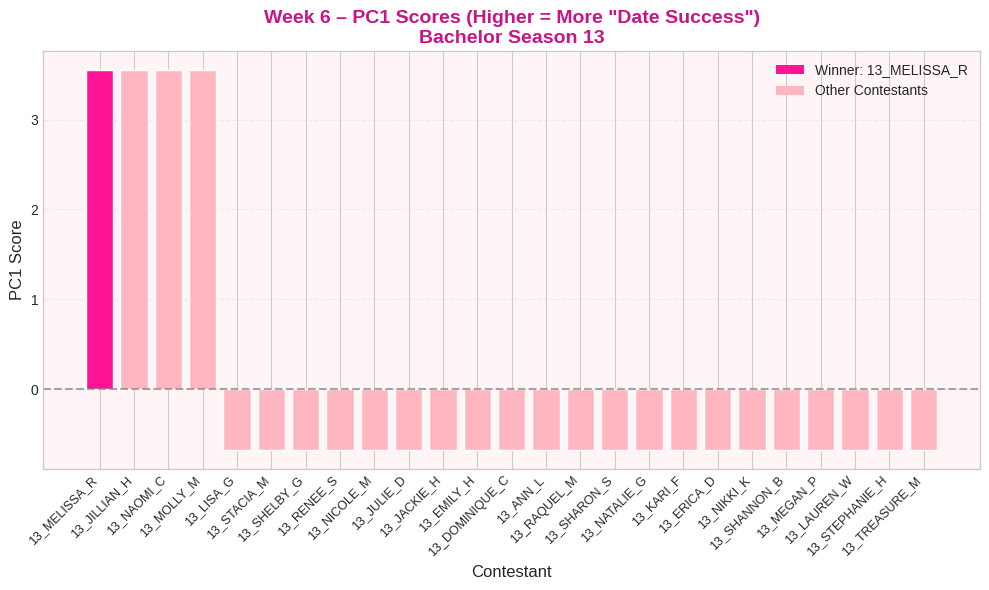

  Saved plot: bachelor_s13_week6_pc1_scores.png

Week 7: 25 contestants, PC1 explains 1.000 of variance
  13_MELISSA_R's PC1 score: 4.122
  Top PC1 loadings:
    Positive: {'ONE_ON_ONE': 0.6569854140345462, 'HAS_DATE': 0.6569854140345457}
    Negative: {'FIRST_IMPRESSION_ROSE': -0.0, 'DATE_GROUP_SIZE': 0.21349498939609243}


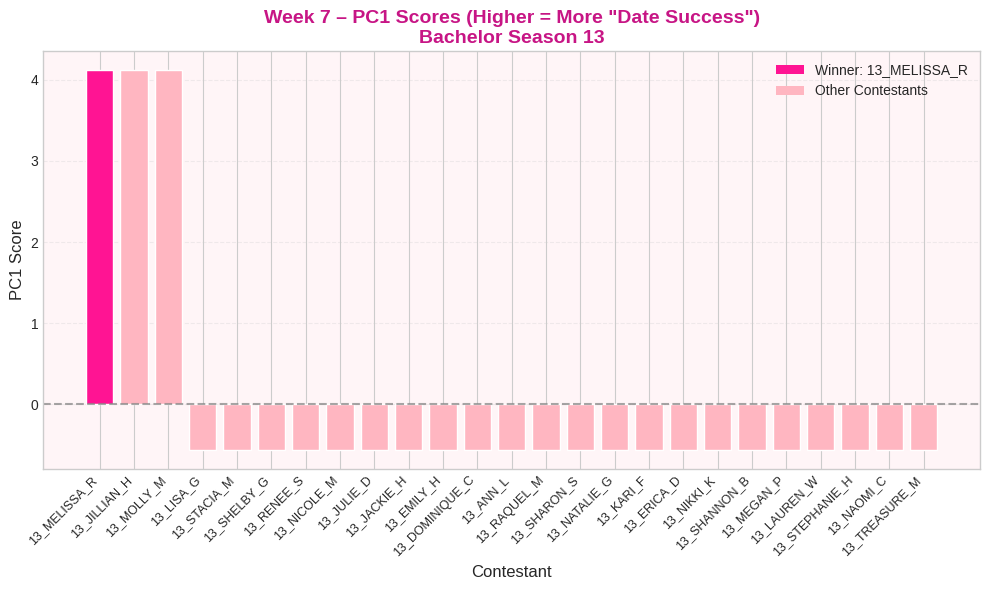

  Saved plot: bachelor_s13_week7_pc1_scores.png

Week 8: 25 contestants, PC1 explains 1.000 of variance
  13_MELISSA_R's PC1 score: 5.054
  Top PC1 loadings:
    Positive: {'HAS_DATE': 0.6710351588687739, 'ONE_ON_ONE': 0.6710351588687737}
    Negative: {'FIRST_IMPRESSION_ROSE': -0.0, 'DATE_GROUP_SIZE': 0.18204727510907645}


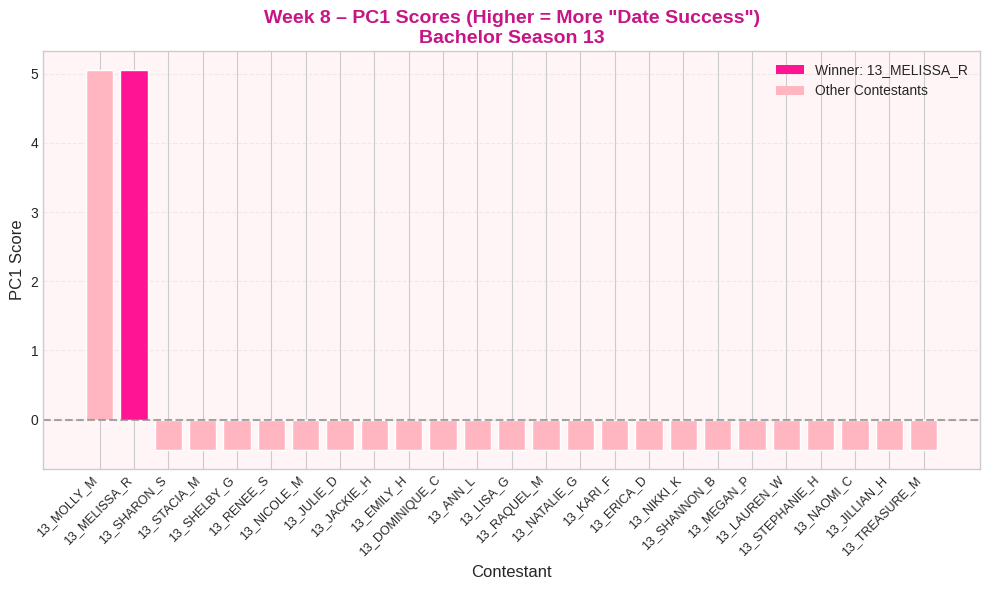

  Saved plot: bachelor_s13_week8_pc1_scores.png

Week 9: 25 contestants, PC1 explains nan of variance
  13_MELISSA_R's PC1 score: 0.000
  Top PC1 loadings:
    Positive: {'HAS_DATE': 1.0, 'ONE_ON_ONE': 0.0}
    Negative: {'ONE_ON_ONE': 0.0, 'DATE_GROUP_SIZE': 0.0}


/home/emchatwin/Kelly Lab/.lab/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:545: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var


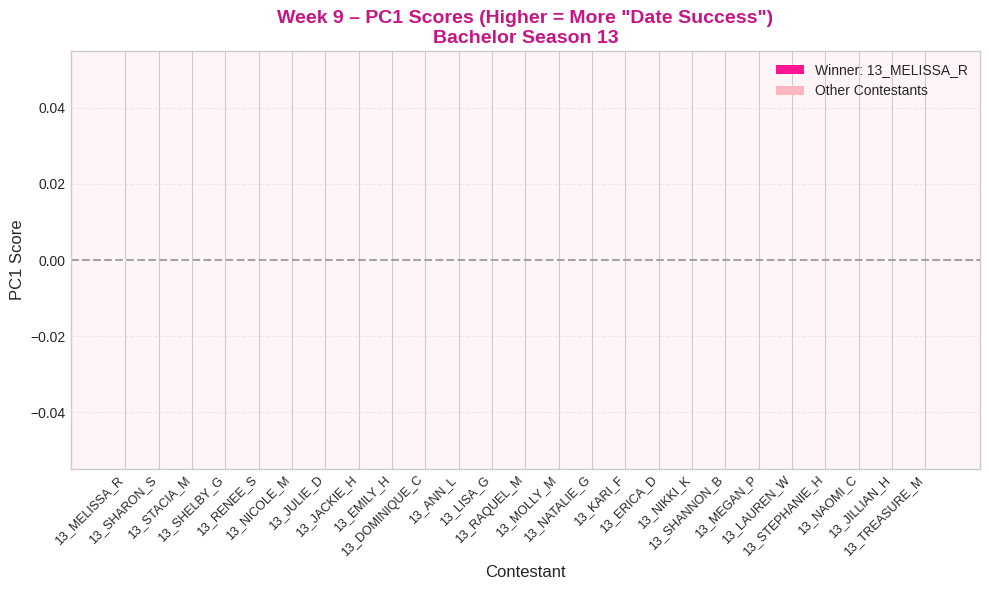

  Saved plot: bachelor_s13_week9_pc1_scores.png

Week 10: 25 contestants, PC1 explains nan of variance
  13_MELISSA_R's PC1 score: 0.000
  Top PC1 loadings:
    Positive: {'HAS_DATE': 1.0, 'ONE_ON_ONE': 0.0}
    Negative: {'ONE_ON_ONE': 0.0, 'DATE_GROUP_SIZE': 0.0}


/home/emchatwin/Kelly Lab/.lab/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:545: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var


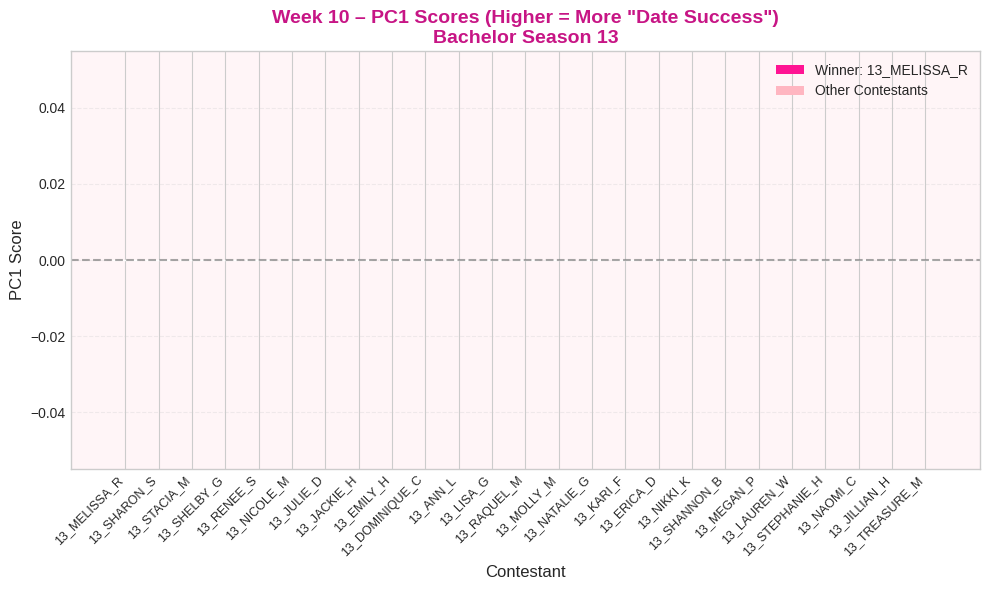

  Saved plot: bachelor_s13_week10_pc1_scores.png


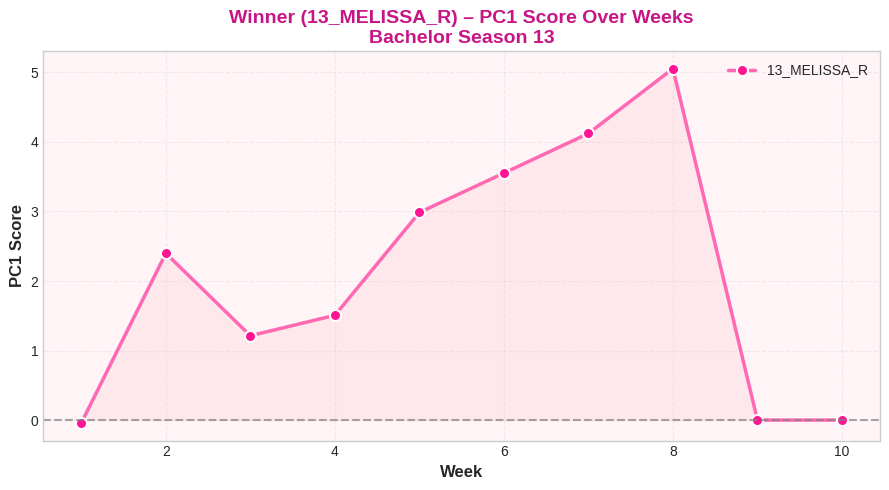


Saved winner trajectory plot as 'bachelor_s13_winner_pc1_trajectory_pink.png'


In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load weekly data
# ------------------------------------------------------------
weekly_df = pd.read_csv('contestant_weekly.csv')

# Select The Bachelor Season 13 (Jason Mesnick)
SHOW_NAME = 'Bachelor'
SEASON_NUM = 13

show_season = weekly_df[(weekly_df['SHOW'] == SHOW_NAME) & (weekly_df['SEASON'] == SEASON_NUM)].copy()
print(f"{SHOW_NAME} Season {SEASON_NUM}: {len(show_season)} rows, {show_season['CONTESTANT'].nunique()} contestants")

if show_season.empty:
    print(f"No data for {SHOW_NAME} Season {SEASON_NUM}. Available:")
    print(weekly_df.groupby(['SHOW', 'SEASON']).size())
    raise SystemExit

# Save all raw data for this season to CSV
output_csv = f'{SHOW_NAME.lower()}_s{SEASON_NUM}_all_data.csv'
show_season.to_csv(output_csv, index=False)
print(f"Saved all raw data to '{output_csv}'")

# Identify winner (final rose in week 10)
winner = show_season[(show_season['WEEK'] == 10) & (show_season['WEEKLY_ROSE'] == 1)]['CONTESTANT'].iloc[0]
print(f"Winner: {winner}\n")

# ------------------------------------------------------------
# Weekly details (dates, one‑on‑ones, roses, eliminations)
# Also collect stats for CSV export
# ------------------------------------------------------------
print("=" * 60)
print(f"WEEKLY DETAILS FOR {SHOW_NAME} SEASON {SEASON_NUM}")
print("=" * 60)

weekly_stats = []  # to store rows for CSV

for week in range(1, 11):
    week_data = show_season[show_season['WEEK'] == week]
    if week_data.empty:
        continue
    
    on_date = week_data[week_data['HAS_DATE'] == 1]['CONTESTANT'].tolist()
    one_on_one = week_data[week_data['ONE_ON_ONE'] == 1]['CONTESTANT'].tolist()
    got_rose = week_data[week_data['WEEKLY_ROSE'] == 1]['CONTESTANT'].tolist()
    eliminated = week_data[week_data['ELIMINATED_THIS_WEEK'] == 1]['CONTESTANT'].tolist()
    
    print(f"\n--- Week {week} ---")
    print(f"  On a date:           {on_date if on_date else 'None'}")
    print(f"  One-on-one dates:    {one_on_one if one_on_one else 'None'}")
    print(f"  Received a rose:     {got_rose if got_rose else 'None'}")
    print(f"  Eliminated:          {eliminated if eliminated else 'None'}")
    
    # Store for CSV
    weekly_stats.append({
        'WEEK': week,
        'ON_DATE': str(on_date),
        'ONE_ON_ONE': str(one_on_one),
        'RECEIVED_ROSE': str(got_rose),
        'ELIMINATED': str(eliminated)
    })

# Save weekly stats to CSV
stats_df = pd.DataFrame(weekly_stats)
stats_csv = f'{SHOW_NAME.lower()}_s{SEASON_NUM}_weekly_summary.csv'
stats_df.to_csv(stats_csv, index=False)
print(f"\nSaved weekly summary to '{stats_csv}'")

# ------------------------------------------------------------
# Weekly PCA analysis + per‑week bar plots of PC1 scores
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("WEEKLY PCA ANALYSIS")
print("=" * 60)

features = ['HAS_DATE', 'ONE_ON_ONE', 'DATE_GROUP_SIZE', 'DATE_RATIO',
            'DATE_ROSE', 'FIRST_IMPRESSION_ROSE']

winner_pc1 = {}

for week in range(1, 11):
    week_data = show_season[show_season['WEEK'] == week].copy()
    if week_data.empty:
        continue
    
    X = week_data[features].copy()
    numeric_cols = ['DATE_GROUP_SIZE', 'DATE_RATIO']
    binary_cols = [c for c in features if c not in numeric_cols]
    scaler = StandardScaler()
    X_numeric = scaler.fit_transform(X[numeric_cols])
    X_scaled = np.hstack([X_numeric, X[binary_cols].values])
    
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)
    
    ev_ratio = pca.explained_variance_ratio_
    print(f"\nWeek {week}: {len(week_data)} contestants, PC1 explains {ev_ratio[0]:.3f} of variance")
    
    week_data = week_data.copy()
    week_data['PC1'] = X_pca[:, 0]
    
    # Winner's PC1 score
    winner_row = week_data[week_data['CONTESTANT'] == winner]
    if not winner_row.empty:
        winner_pc1[week] = winner_row['PC1'].iloc[0]
        print(f"  {winner}'s PC1 score: {winner_pc1[week]:.3f}")
    
    # Top loadings
    loadings = pd.Series(pca.components_[0], index=features)
    print("  Top PC1 loadings:")
    print(f"    Positive: {loadings.nlargest(2).to_dict()}")
    print(f"    Negative: {loadings.nsmallest(2).to_dict()}")
    
    # --------------------------------------------------------
    # Create a pretty pink bar plot of PC1 scores for this week
    # --------------------------------------------------------
    # Sort by PC1 score for better visualization
    plot_data = week_data.sort_values('PC1', ascending=False)
    contestants = plot_data['CONTESTANT'].tolist()
    pc1_scores = plot_data['PC1'].tolist()
    
    # Assign colors: winner in dark pink, others in light pink
    colors = ['#FF1493' if c == winner else '#FFB6C1' for c in contestants]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(contestants, pc1_scores, color=colors, edgecolor='white', linewidth=1)
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
    plt.xlabel('Contestant', fontsize=12)
    plt.ylabel('PC1 Score', fontsize=12)
    plt.title(f'Week {week} – PC1 Scores (Higher = More "Date Success")\n{SHOW_NAME} Season {SEASON_NUM}', 
              fontsize=14, fontweight='bold', color='#C71585')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add a legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#FF1493', label=f'Winner: {winner}'),
                       Patch(facecolor='#FFB6C1', label='Other Contestants')]
    plt.legend(handles=legend_elements, loc='upper right')
    
    ax = plt.gca()
    ax.set_facecolor('#FFF5F7')
    plt.tight_layout()
    
    plot_filename = f'{SHOW_NAME.lower()}_s{SEASON_NUM}_week{week}_pc1_scores.png'
    plt.savefig(plot_filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved plot: {plot_filename}")

# ------------------------------------------------------------
# (Optional) Winner's PC1 trajectory plot (pink)
# ------------------------------------------------------------
if winner_pc1:
    weeks = sorted(winner_pc1.keys())
    scores = [winner_pc1[w] for w in weeks]

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(9, 5))
    
    plt.plot(weeks, scores, marker='o', linestyle='-', 
             color='#FF69B4', linewidth=2.5, markersize=8, 
             markerfacecolor='#FF1493', markeredgecolor='white', markeredgewidth=1.5,
             label=winner)
    
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
    plt.xlabel('Week', fontsize=12, fontweight='semibold')
    plt.ylabel('PC1 Score', fontsize=12, fontweight='semibold')
    plt.title(f'Winner ({winner}) – PC1 Score Over Weeks\n{SHOW_NAME} Season {SEASON_NUM}', 
              fontsize=14, fontweight='bold', color='#C71585')
    
    plt.fill_between(weeks, scores, 0, alpha=0.2, color='#FFB6C1')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(loc='best', framealpha=0.9, edgecolor='pink')
    
    ax = plt.gca()
    ax.set_facecolor('#FFF5F7')
    plt.tight_layout()
    
    trajectory_plot = f'{SHOW_NAME.lower()}_s{SEASON_NUM}_winner_pc1_trajectory_pink.png'
    plt.savefig(trajectory_plot, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nSaved winner trajectory plot as '{trajectory_plot}'")
else:
    print("\nNo winner PC1 scores to plot.")